In [1]:
import anndata as ad
import torch
import pytorch_lightning as pl  # pyright: ignore[reportMissingImports]
from src.dataset import ScDataModule
from src.ae import LightningAE
import scanpy as sc  # pyright: ignore[reportMissingImports]
import os
import numpy as np
from src.utils import compare_umap


adata = ad.read_h5ad('data/Alles_filtered.h5ad')
adata.var_names_make_unique()
display(adata.X)
display(adata.obs)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adatamodule = ScDataModule(adata, "cell_type1", "LabelEncoder")
ae_model = LightningAE(n_genes=adata.X.shape[1])

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/ae"
)

ae_model_path = "checkpoints/trained_ae_model.ckpt"
if os.path.exists(ae_model_path):
    # read the model from the checkpoint
    ae_model = LightningAE.load_from_checkpoint("checkpoints/trained_ae_model.ckpt")
else:
    trainer.fit(ae_model, adatamodule)
    trainer.save_checkpoint(ae_model_path)
    
X_dense = adata.X.toarray()

# Convert to torch tensor and move to same device as model
device = next(ae_model.parameters()).device
X_tensor = torch.tensor(X_dense, dtype=torch.float32).to(device)

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/tqdm/auto.py:21: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 5236395 stored elements and shape (4614, 11835)>

,cell_type1,data_type,cell_ontology_class,n_genes,n_counts
cell_id,,,,,
ACTTAGCGTTTN,undifferentiated cells,raw,nan,1588,5416
ATACACCCGCCC,undifferentiated cells,raw,nan,1165,4032
TCGGCGATGTAT,undifferentiated cells,raw,nan,1134,3992
GTTCGCCGTCGA,undifferentiated cells,raw,nan,1706,8109
CTAATCGCTAGT,undifferentiated cells,raw,nan,810,2743
...,...,...,...,...,...
TTTTAAGACGGN,LVM longitudinal visc. muscle,raw,visceral muscle cell,1027,3737
TCTTCACGAAGA,LVM longitudinal visc. muscle,raw,visceral muscle cell,1548,5824
GTTGCAATGGAG,LVM longitudinal visc. muscle,raw,visceral muscle cell,1136,3099


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [2]:
from src.lightning_diffusion import LightningDiffusion
ae_model.eval()
with torch.no_grad():
    latent = ae_model.encode(X_tensor).cpu().numpy()  # shape [n_cells, latent_dim]

# standardize the latent space
latent = (latent - latent.mean(axis=0)) / latent.std(axis=0)
latent_adata = ad.AnnData(latent, obs=adata.obs.copy())

latent_dm = ScDataModule(latent_adata, label_key="cell_type1",
                        encoder="LabelEncoder", batch_size=128, val_split=0.1)
latent_dm.setup()

dim = latent.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1

diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes
)

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/diffusion"
)

diffusion_model_path = "checkpoints/trained_diffusion_model.ckpt"
if os.path.exists(diffusion_model_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion, latent_dm)
    trainer.save_checkpoint(diffusion_model_path)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


DDIM sampling:   0%|          | 0/50 [00:00<?, ?it/s]

DDIM sampling: 100%|██████████| 50/50 [00:25<00:00,  1.94it/s]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (9228 samples, 128 features)...
UMAP completed. Generating visualizations...


(array([[-45.310345, -21.325672],
        [-43.01707 , -19.609293],
        [-44.399853, -19.19687 ],
        ...,
        [-43.14292 , -20.27095 ],
        [-47.798664, -16.688652],
        [-45.933575, -18.802202]], shape=(4614, 2), dtype=float32),
 array([[-41.471146, -22.915592],
        [-47.058002, -18.166348],
        [-48.85035 , -19.351313],
        ...,
        [-47.857037, -16.751394],
        [-45.92063 , -26.355421],
        [-41.681904, -22.810673]], shape=(4614, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

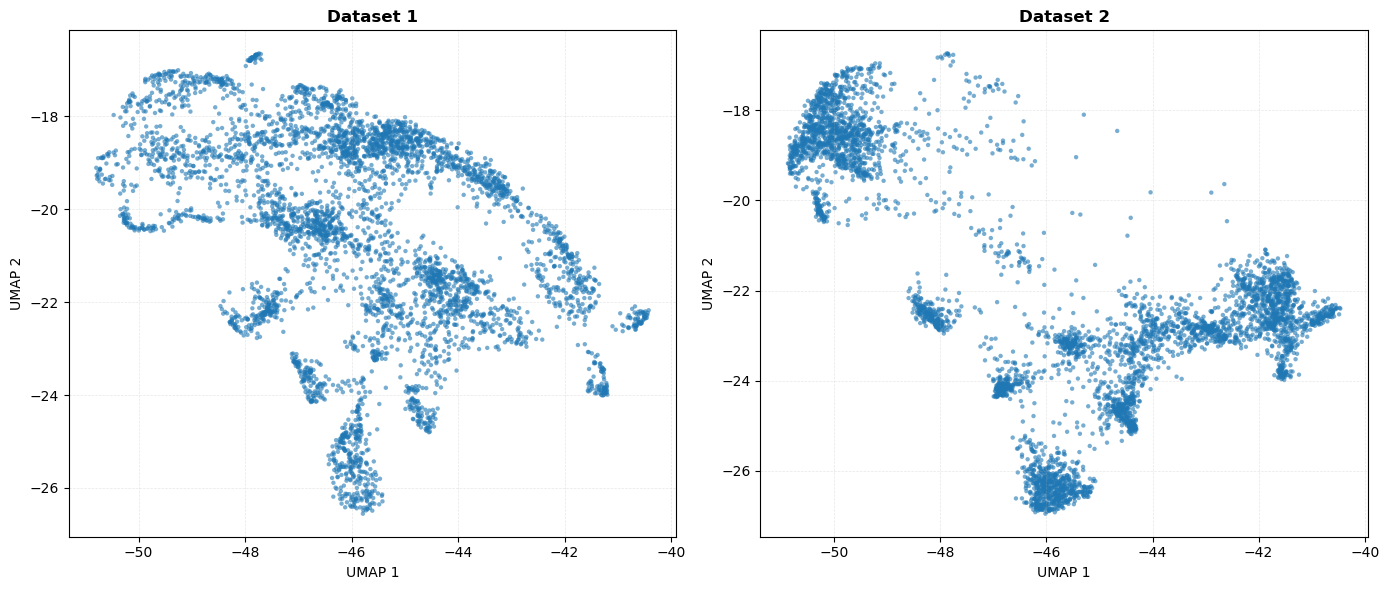

In [4]:
real_labels = latent_dm.train_dataset.dataset.classes
device = next(diffusion.parameters()).device
labels_tensor = torch.tensor(real_labels, dtype=torch.long).to(device)


latent_samples = diffusion.sample(num_samples=len(latent_adata),
                                      sampling_timesteps=50,
                                    labels=labels_tensor,
                                    ddim_sampling_eta=0.1,
                                    clip_denoised=False)
compare_umap(latent_adata.X, latent_samples)

DDIM sampling: 100%|██████████| 999/999 [12:28<00:00,  1.34it/s]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (9228 samples, 128 features)...
UMAP completed. Generating visualizations...


(array([[ 6.1728425 , 16.642265  ],
        [-0.9843118 , 14.832456  ],
        [-0.17290889, 14.025017  ],
        ...,
        [-0.88864315, 15.229164  ],
        [ 1.6666994 ,  6.5835605 ],
        [ 1.6378101 , 15.478302  ]], shape=(4614, 2), dtype=float32),
 array([[ 2.4454067 , 11.951676  ],
        [ 3.141118  , 11.892432  ],
        [ 1.7068169 , 12.089713  ],
        ...,
        [ 3.585067  , 12.544838  ],
        [ 2.3014863 , 12.367896  ],
        [ 0.25177172, 11.522417  ]], shape=(4614, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

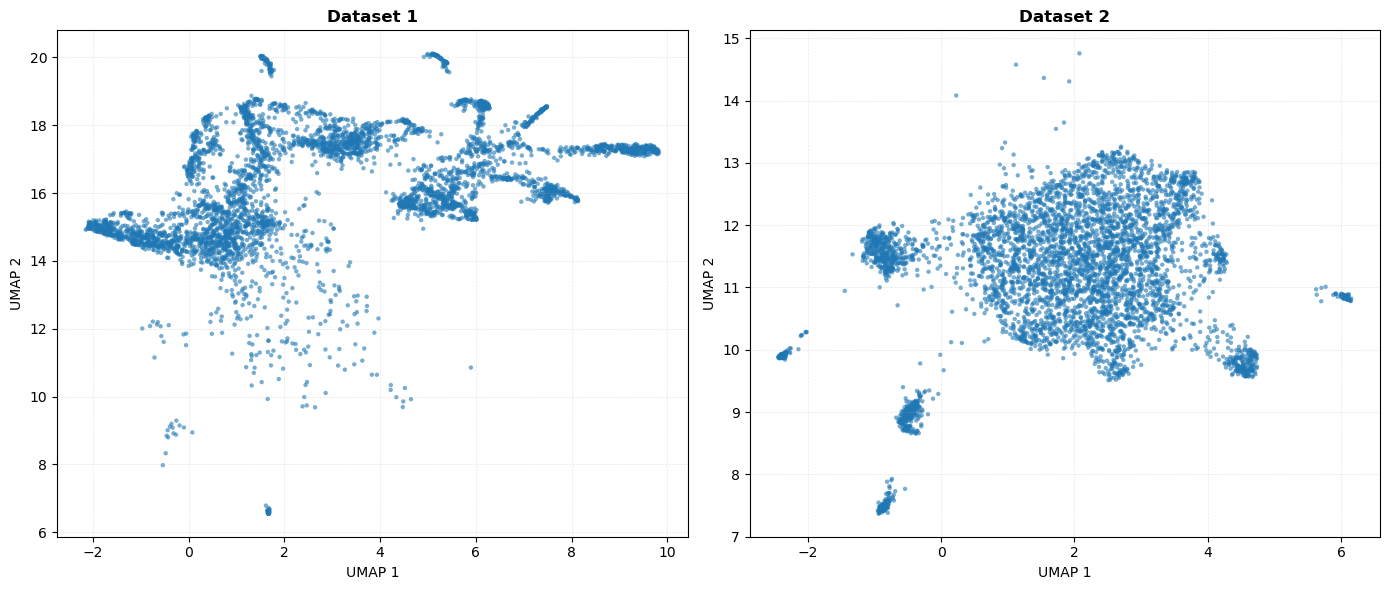

In [7]:
ddim999_latent_samples = diffusion.sample(num_samples=len(latent_adata),
                                    labels=labels_tensor,
                                    sampling_timesteps=999)
compare_umap(latent_adata.X, ddim999_latent_samples)

DDIM sampling:   0%|          | 0/50 [00:00<?, ?it/s]

DDIM sampling: 100%|██████████| 50/50 [00:26<00:00,  1.86it/s]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (9228 samples, 128 features)...
UMAP completed. Generating visualizations...


(array([[12.093264 , 24.833824 ],
        [ 3.6353095, 24.10645  ],
        [ 4.606498 , 23.754663 ],
        ...,
        [ 3.656714 , 24.550428 ],
        [ 2.4928186, 21.432299 ],
        [ 6.3425236, 25.11423  ]], shape=(4614, 2), dtype=float32),
 array([[ 8.852951 , 23.478333 ],
        [ 9.133375 , 23.493824 ],
        [ 9.05409  , 23.244211 ],
        ...,
        [ 8.753298 , 22.1508   ],
        [ 8.148188 , 20.724834 ],
        [ 6.9186993, 22.186829 ]], shape=(4614, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

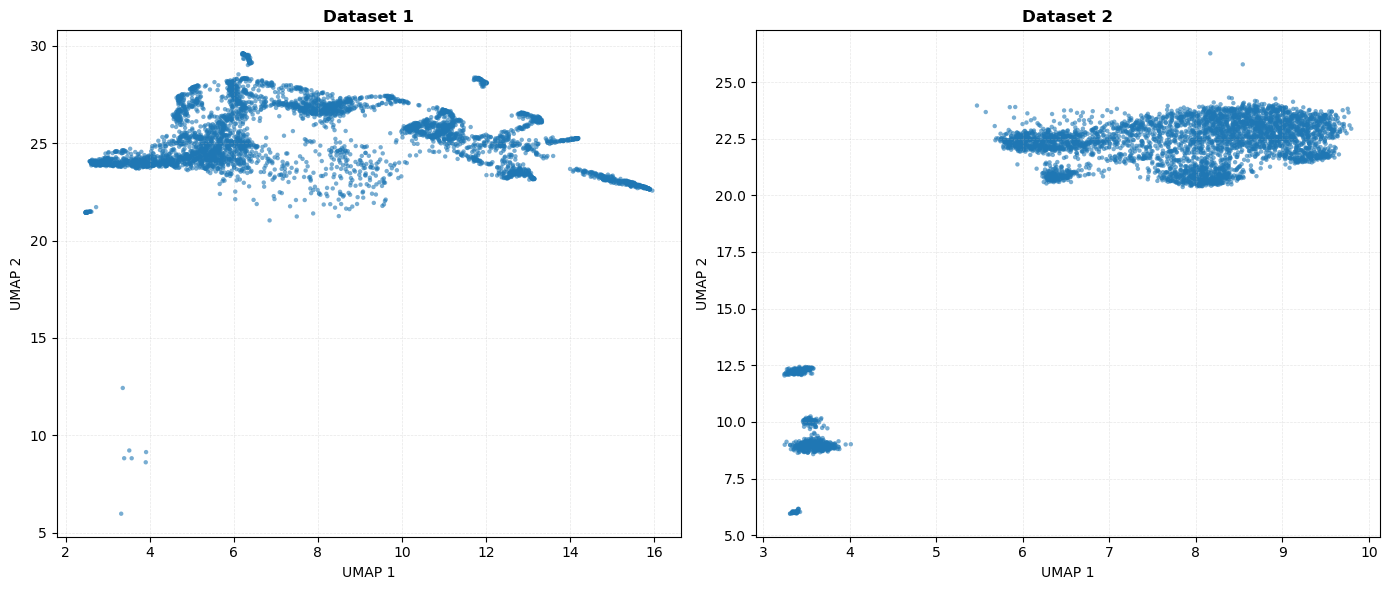

In [13]:
diffusion.diffusion.ddim_sampling_eta = 0
ddim50_latent_samples = diffusion.sample(num_samples=len(latent_adata),
                                    labels=labels_tensor,
                                    sampling_timesteps=50,
                                    guidance_scale=6.0)
compare_umap(latent_adata.X, ddim50_latent_samples)

sampling loop time step: 100%|██████████| 1000/1000 [14:22<00:00,  1.16it/s]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (9228 samples, 128 features)...
UMAP completed. Generating visualizations...


(array([[-1.4573547 ,  2.2384236 ],
        [-2.055374  ,  0.2298616 ],
        [-0.81144387,  1.200741  ],
        ...,
        [-1.8203992 ,  1.6146803 ],
        [ 4.0850587 ,  2.6751034 ],
        [ 1.8645918 ,  1.1733358 ]], shape=(4614, 2), dtype=float32),
 array([[-0.7900041 ,  0.6724531 ],
        [ 0.4629117 ,  1.6252977 ],
        [ 1.182541  ,  2.4315815 ],
        ...,
        [ 0.15965272,  3.207157  ],
        [ 1.7872752 ,  1.2110951 ],
        [ 0.91774255,  2.6638813 ]], shape=(4614, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

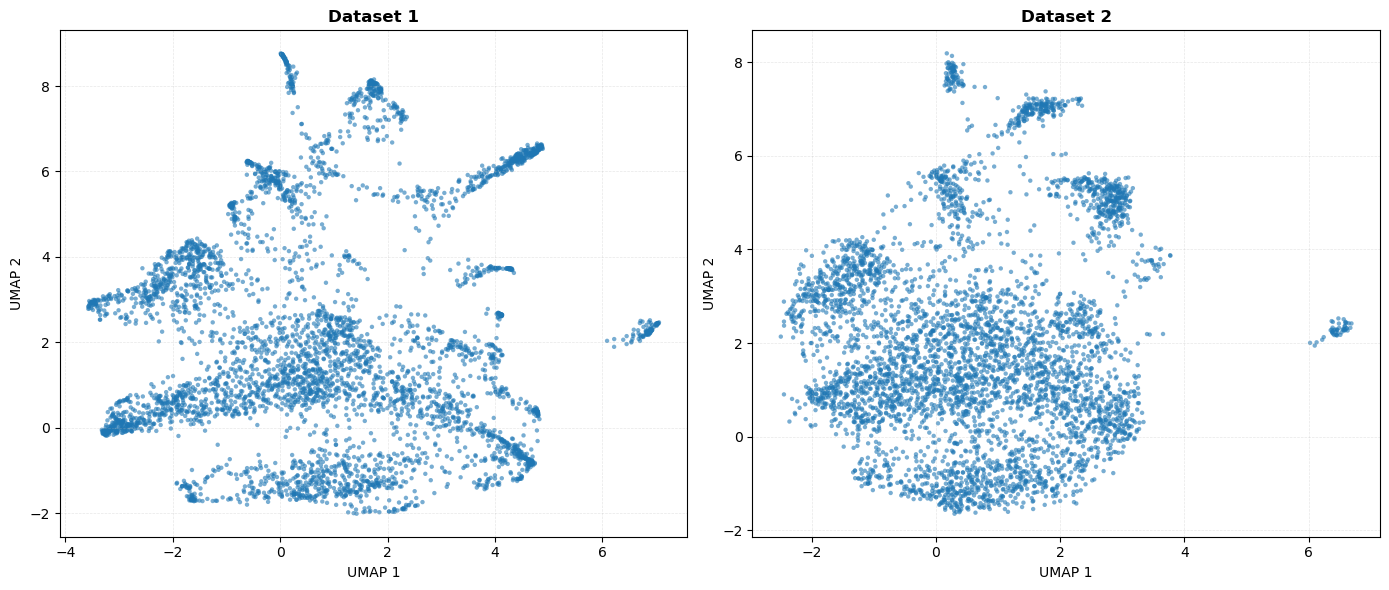

In [12]:
ddpm_latent_samples = diffusion.sample(num_samples=len(latent_adata),
                                    labels=labels_tensor,
                                    sampling_timesteps=None)
compare_umap(latent_adata.X, ddpm_latent_samples)

  Class 0: 47 (1.0%)
  Class 1: 199 (4.3%)
  Class 2: 650 (14.1%)
  Class 3: 221 (4.8%)
  Class 4: 82 (1.8%)
  Class 5: 82 (1.8%)
  Class 6: 339 (7.3%)
  Class 7: 107 (2.3%)
  Class 8: 308 (6.7%)
  Class 9: 545 (11.8%)
  Class 10: 155 (3.4%)
  Class 11: 1512 (32.8%)
  Class 12: 248 (5.4%)
  Class 13: 119 (2.6%)


sampling loop time step: 100%|██████████| 1000/1000 [16:58<00:00,  1.02s/it]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



生成数据类别分布:
  Class 0: 47 (1.0%)
  Class 1: 199 (4.3%)
  Class 2: 650 (14.1%)
  Class 3: 221 (4.8%)
  Class 4: 82 (1.8%)
  Class 5: 82 (1.8%)
  Class 6: 339 (7.3%)
  Class 7: 107 (2.3%)
  Class 8: 308 (6.7%)
  Class 9: 545 (11.8%)
  Class 10: 155 (3.4%)
  Class 11: 1512 (32.8%)
  Class 12: 248 (5.4%)
  Class 13: 119 (2.6%)
Performing UMAP on combined dataset (9228 samples, 128 features)...
UMAP completed. Generating visualizations...


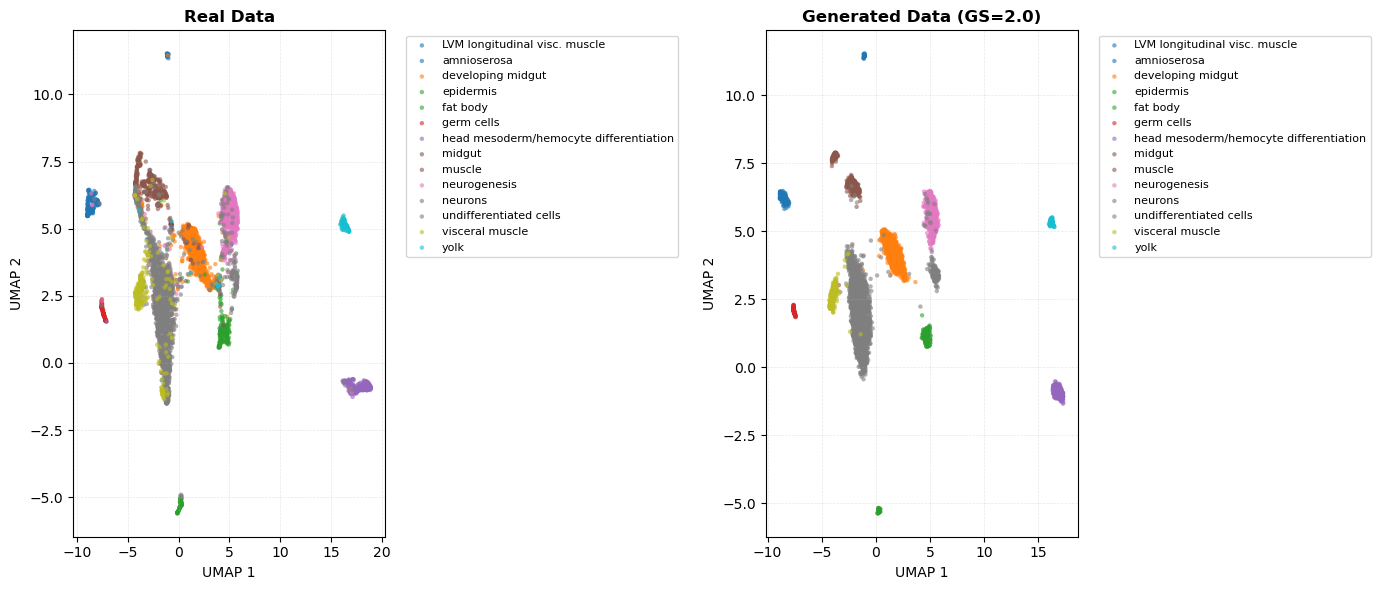

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(latent_adata.obs['cell_type1'])
full_labels = le.transform(latent_adata.obs['cell_type1'])

unique_labels, counts = np.unique(full_labels, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f"  Class {label}: {count} ({count/len(full_labels)*100:.1f}%)")

device = next(diffusion.parameters()).device
labels_tensor = torch.tensor(full_labels, dtype=torch.long).to(device)

diffusion.eval()
with torch.no_grad():
    latent_samples = diffusion.sample(
        num_samples=len(full_labels),
        labels=labels_tensor,
        guidance_scale=2.0, 
        use_ema=True,
        sampling_timesteps = None
    )

print("\n生成数据类别分布:")
unique_gen, counts_gen = np.unique(full_labels, return_counts=True)
for label, count in zip(unique_gen, counts_gen):
    print(f"  Class {label}: {count} ({count/len(full_labels)*100:.1f}%)")


emb1, emb2, fig = compare_umap(
    latent_adata.X, 
    latent_samples.cpu().numpy(),
    labels1=le.inverse_transform(full_labels),  
    labels2=le.inverse_transform(full_labels),
    title1="Real Data",
    title2="Generated Data (GS=2.0)",
    random_state=42
)
